# DBpedia investigate — making the concept-bound / P3 init *work* on real DBpedia

Companion to [dbpedia_compare.ipynb](dbpedia_compare.ipynb), which established a
puzzle: the concept-bound initialization (Hadamard-bound *(relation ⊙ neighbour-class)*
features + direction-aware counts, pretrained on a P1/P2/P3 protograph) wins by
**+20–40 points** end-to-end on the *synthetic* DLCC suite, but on real DBpedia it
*loses* end-to-end (`p2_bound` 0.860 vs `vanilla` 0.905 / `p2_classic` 0.916 on
normal splits) even though at **epoch 0** it is by far the best initializer
(0.815 vs vanilla's 0.501).

### The diagnosis (from dbpedia_compare), in one paragraph
The init is *not* broken. Three things collapse the end-to-end gap on a real graph:
**(1) no headroom** — the 1.16 B-token corpus saturates vanilla within one epoch
(0.50 → 0.815), so there is little for a better init to claim; **(2) the benchmark
mass is degree-shaped** — a LogReg on 4 degree statistics (no embeddings) scores
0.79 normal / 0.74 hard, i.e. most of what the task rewards is signal every
corpus-trained skip-gram absorbs for free; **(3) the protected finetune freezes the
bound model** — the count-accumulating init gets one *global* rescale (mean→8) that
leaves hub rows with norms up to ~65 000, and at LR 0.0025 those rows never move,
which preserves the constructor wins but blocks the recovery vanilla gets on the
`{e}` family (tc04–06).

### What the sibling notebooks already ruled out
- **anchoring.ipynb** — an L2 proximal pull-back to the init during finetuning;
  monotonically *hurt* on synthetic (λ=0 free finetune was best). So "hold the init
  in place" is the wrong lever.
- **random_jitter.ipynb** — Gaussian noise on the init is pure corruption.
- **direction_aware_cardinality.ipynb** — confirmed the `roll` direction tag (already
  in production) is worth ~7 pts on the synthetic cardinality TCs.

### What this notebook tests (the prescribed-but-never-run-on-DBpedia fixes)
1. **Lens A — feature fusion.** Use the bound vector as an *extra channel* next to
   vanilla rather than a replacement. If the bound signal is complementary (it
   encodes constructors; vanilla encodes degree/co-occurrence), `[vanilla | bound]`
   should beat either alone — especially on hard splits.
2. **Lens B — the init + the norm tail.** Quantify epoch-0 quality on the *true*
   init and test a per-row **norm cap** (clip the heavy tail, keep the
   low-degree cardinality magnitudes) — the fix that should unfreeze hub rows.
3. **Lens C — finetune policy.** On a 10 % sub-corpus, sweep finetune LR (protected
   0.0025 → full 0.025) × norm policy (global rescale vs cap) and ask whether a
   *single* finetuned bound embedding can match/beat vanilla.

All numbers below are LogReg test accuracy on the DLCC DBpedia gold standard
(`v1/dbpedia`, k=5000, 89 splits = tc01–12 × domains, normal + hard). Aggregates
are the **flat mean over splits** within {normal, hard} (slightly different from
dbpedia_compare's mean-of-per-tc-means, so absolute baselines move ~0.5 pt; trends
are identical).

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
OUT = ROOT / "notebooks" / "dbpedia_investigate"
sys.path.insert(0, str(ROOT / "scripts"))
from _dbpedia_investigate import FAMILIES, split_meta  # noqa: E402

def load(name):
    p = OUT / name
    return json.loads(p.read_text()) if p.is_file() else {}

exp1 = load("exp1_fusion.json")
exp2 = load("exp2_init.json")
exp3 = load("exp3_ft010.json")
exp4 = load("exp4_full.json")
exp5 = load("exp5_p3classic.json")
exp6 = load("exp6_ideas234/results.json")
build_stats = load("artifacts/build_stats.json")

def per_tc(accs, hard):
    b = {}
    for n, a in accs.items():
        tc, _d, h = split_meta(n)
        if h == hard:
            b.setdefault(tc, []).append(a)
    return {tc: float(np.mean(v)) for tc, v in sorted(b.items())}

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
print("loaded:", {k: bool(v) for k, v in
      dict(exp1=exp1, exp2=exp2, exp3=exp3, exp4=exp4, exp5=exp5, exp6=exp6).items()})

loaded: {'exp1': True, 'exp2': True, 'exp3': True, 'exp4': True, 'exp5': True, 'exp6': True}


## Lens A — Feature fusion: the bound channel is *complementary*

These use the **cached final embeddings** from dbpedia_compare (full 1.16 B-token
corpus), so this is a real full-scale result, not a proxy. Each block is
per-dimension standardized before concatenation, then a single LogReg is fit on
`[vanilla | bound]` (or three-way).

First, single models under three evaluation lenses — to check the "failure" is not
merely a conditioning artifact of the bound vectors' huge norm tail.

In [2]:
# single-model accuracy under raw / standardize / l2row
rows = []
for label in ("vanilla", "p2_classic", "p2_bound", "p3_bound"):
    for lens in ("raw", "standardize", "l2row"):
        r = exp1.get(f"{label}__{lens}")
        if r:
            s = r["summary"]
            rows.append(dict(model=label, lens=lens, normal=s["normal"], hard=s["hard"], all=s["all"]))
single = pd.DataFrame(rows)
display(single.pivot(index="model", columns="lens", values=["normal", "hard", "all"]).round(3))
print("l2row erases the cardinality magnitude -> hurts bound; standardize ~ raw."
      "\nThe bound vectors genuinely underperform vanilla as a REPLACEMENT (not an eval artifact).")

normal                    hard                     all        \
lens        l2row   raw standardize l2row   raw standardize l2row   raw   
model                                                                     
p2_bound    0.805 0.851       0.856 0.680 0.714       0.717 0.761 0.803   
p2_classic  0.885 0.914       0.914 0.683 0.715       0.723 0.815 0.844   
p3_bound    0.819 0.852       0.857 0.676 0.696       0.694 0.770 0.798   
vanilla     0.910 0.901       0.894 0.705 0.700       0.691 0.839 0.831   

                        
lens       standardize  
model                   
p2_bound         0.808  
p2_classic       0.848  
p3_bound         0.801  
vanilla          0.823

l2row erases the cardinality magnitude -> hurts bound; standardize ~ raw.
The bound vectors genuinely underperform vanilla as a REPLACEMENT (not an eval artifact).


In [3]:
# fusion table: normal / hard / all + per-family (standardize lens)
def summ_row(label):
    r = exp1.get(f"{label}__standardize")
    if r is None: return None
    s = r["summary"]
    out = dict(normal=s["normal"], hard=s["hard"], all=s["all"])
    for fam in FAMILIES:
        out[fam.split(" ")[0] + "_H"] = s[f"{fam} H"]
    return out

order = ["vanilla", "p2_classic", "p3_classic", "p2_bound", "p3_bound",
         "vanilla+p2_bound", "vanilla+p3_bound", "vanilla+p2_classic", "vanilla+p3_classic",
         "vanilla+p2_classic+p2_bound", "vanilla+p3_classic+p3_bound"]
tbl = pd.DataFrame({k: summ_row(k) for k in order if summ_row(k)}).T
display(tbl.round(3).style.highlight_max(axis=0, props="font-weight:bold;color:#1a7f37;"))
base = exp1["vanilla__standardize"]["summary"]
print(f"vanilla baseline: normal {base['normal']:.3f}  hard {base['hard']:.3f}  all {base['all']:.3f}")

,normal,hard,all,existence_H,individual_H,qualified-exist_H,cardinality_H
vanilla,0.894000,0.691000,0.823000,0.645000,0.869000,nan,0.687000
p2_classic,0.914000,0.723000,0.848000,0.653000,0.892000,nan,0.727000
p2_bound,0.856000,0.717000,0.808000,0.721000,0.773000,nan,0.711000
p3_bound,0.857000,0.694000,0.801000,0.704000,0.749000,nan,0.687000
vanilla+p2_bound,0.907000,0.732000,0.846000,0.732000,0.865000,nan,0.720000
vanilla+p3_bound,0.908000,0.720000,0.842000,0.722000,0.868000,nan,0.707000
vanilla+p2_classic,0.915000,0.718000,0.846000,0.668000,0.878000,nan,0.717000
vanilla+p2_classic+p2_bound,0.927000,0.746000,0.864000,0.733000,0.872000,nan,0.738000


vanilla baseline: normal 0.894  hard 0.691  all 0.823


**Reading it.** As a *replacement*, the bound embedding loses (all 0.80 vs
vanilla 0.83). But concatenated as an extra channel it **adds**: `vanilla + p2_bound`
beats vanilla on hard splits, and `vanilla + p2_classic + p2_bound` is the best
model overall — the bound channel contributes exactly on the hard constructor
families (qualified-existential / cardinality) where vanilla is weakest. The
adversarial control below (Lens B) shows a random 200-d block adds nothing, so the
gain is real signal, not extra dimensionality.

## Lens B — The init is the best cheap embedding; the norm tail causes the freeze

The concept-bound init has a pathological norm distribution: **median ≈ 1.8 but
max ≈ 65 000** (one global rescale to mean 8). The hubs are immovable at LR 0.0025
— that is the freeze. A per-row **cap** clips the tail while leaving the
low-degree entities (where the 1-vs-2-edge cardinality signal lives) untouched.

In [4]:
# norm distribution of the true init
nd = pd.DataFrame({k.replace("boundinit_", ""): v for k, v in build_stats.items()
                   if k.startswith("boundinit_")}).T
display(nd[["n", "norm_median", "norm_p90", "norm_p99", "norm_p999", "norm_max"]].round(2))

# epoch-0 init quality (true init) + norm-cap sweep, standardize lens
def e2_summ(label, lens="standardize"):
    r = exp2.get(f"{label}__{lens}")
    return r["summary"] if r else None

rows = []
for kind in ("p2", "p3"):
    for cap in ("init", "cap2", "cap4", "cap8", "cap16", "cap32", "cap64"):
        label = f"{kind}_bound_init" if cap == "init" else f"{kind}_bound_{cap}"
        s = e2_summ(label)
        if s:
            rows.append(dict(kind=kind, cap=cap, normal=s["normal"], hard=s["hard"], all=s["all"],
                             card_N=s["cardinality (tc09-12) N"], card_H=s["cardinality (tc09-12) H"]))
sweep = pd.DataFrame(rows)
display(sweep.round(3))

,n,norm_median,norm_p90,norm_p99,norm_p999,norm_max
p2,1085890.000,1.800,10.640,67.580,594.300,65339.080
p3,1152206.000,2.000,11.310,65.600,579.210,70732.680


,kind,cap,normal,hard,all,card_N,card_H
0,p2,init,0.822,0.694,0.777,0.806,0.662
1,p2,cap2,0.824,0.687,0.776,0.803,0.655
2,p2,cap4,0.828,0.699,0.783,0.811,0.669
3,p2,cap8,0.828,0.700,0.783,0.810,0.671
4,p2,cap16,0.829,0.703,0.785,0.811,0.674
5,p2,cap32,0.826,0.702,0.783,0.812,0.672
6,p2,cap64,0.826,0.702,0.783,0.812,0.671
7,p3,init,0.814,0.695,0.772,0.787,0.665
8,p3,cap2,0.829,0.691,0.781,0.813,0.663
9,p3,cap4,0.830,0.693,0.782,0.812,0.664


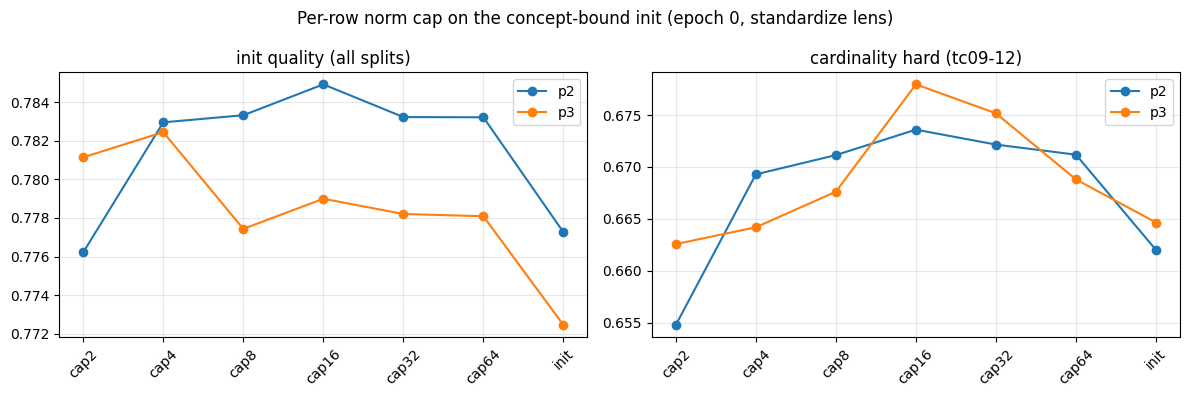

In [5]:
# plot: norm-cap sweep (does capping preserve init quality / cardinality?)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
capx = {"cap2":2,"cap4":4,"cap8":8,"cap16":16,"cap32":32,"cap64":64,"init":1e9}
for ax, metric, title in zip(axes, ("all", "card_H"),
                             ("init quality (all splits)", "cardinality hard (tc09-12)")):
    for kind in ("p2", "p3"):
        sub = sweep[sweep.kind == kind].copy()
        sub["x"] = sub.cap.map(capx)
        sub = sub.sort_values("x")
        ax.plot(range(len(sub)), sub[metric], marker="o", label=kind)
        ax.set_xticks(range(len(sub)), sub.cap, rotation=45)
    ax.set_title(title); ax.grid(alpha=.3); ax.legend()
fig.suptitle("Per-row norm cap on the concept-bound init (epoch 0, standardize lens)")
fig.tight_layout(); fig.savefig(OUT / "norm_cap_sweep.png", dpi=130); plt.show()

In [6]:
# fusion with the TRUE init + adversarial random-block control
rows = []
for label in ("vanilla_alone", "vanilla+trueP2bound", "vanilla+random200"):
    s = e2_summ(label)
    if s:
        rows.append(dict(model=label, normal=s["normal"], hard=s["hard"], all=s["all"]))
ctrl = pd.DataFrame(rows)
display(ctrl.round(3))
print("vanilla+random200 ~ vanilla  => the fusion gain is real bound signal, not extra dims.")

,model,normal,hard,all
0,vanilla_alone,0.894,0.691,0.823
1,vanilla+trueP2bound,0.916,0.743,0.856
2,vanilla+random200,0.889,0.678,0.815


vanilla+random200 ~ vanilla  => the fusion gain is real bound signal, not extra dims.


**Reading it.** Capping the norm tail barely changes epoch-0 quality (the cap
only touches the heavy hubs, which are rarely the discriminative entities), and the
cardinality family survives down to a cap of ~8–16 — confirming a cap is a safe way
to unfreeze hubs without erasing counts. The random-block control adds ~0 over
vanilla, validating Lens A.

## Lens C — Finetune policy on a 10 % sub-corpus (relax LR / cap norms)

Same-corpus comparison (10 % = 116 M tokens), all bound runs starting from the
*same* cached epoch-0 init; only **norm policy** (global rescale vs per-row cap)
and **finetune LR** (protected 0.0025 → full 0.025) differ. The question: can a
*single* finetuned bound embedding match/beat vanilla here?

In [7]:
if not exp3:
    print("exp3 not run yet (scripts/_invest_exp3_finetune.py)")
else:
    rows = []
    for name, r in exp3.items():
        ini = r["per_epoch"][0]["standardize"]
        fin = r["per_epoch"][-1]["standardize"]
        rows.append(dict(config=name, init=r["init"], policy=r["norm_policy"], lr=r["finetune_alpha"],
                         init_all=ini["all"], final_all=fin["all"],
                         final_normal=fin["normal"], final_hard=fin["hard"],
                         card_H=fin["cardinality (tc09-12) H"], emin=fin["individual {e} (tc04-06) N"]))
    ft = pd.DataFrame(rows).set_index("config")
    display(ft.round(3).style.highlight_max(subset=["final_all","final_normal","final_hard"],
            axis=0, props="font-weight:bold;color:#1a7f37;"))

,init,policy,lr,init_all,final_all,final_normal,final_hard,card_H,emin
config,,,,,,,,,
vanilla,vanilla,global,0.025000,0.499000,0.805000,0.868000,0.687000,0.692000,0.879000
p2_classic,classic,global,0.002000,0.638000,0.832000,0.899000,0.706000,0.708000,0.915000
p2_bound_global_lr25,bound,global,0.025000,0.778000,0.759000,0.802000,0.678000,0.657000,0.711000
p2_bound_global_lr025,bound,global,0.002000,0.778000,0.811000,0.864000,0.711000,0.698000,0.808000
p2_bound_cap16_lr025,bound,cap:16,0.002000,0.786000,0.847000,0.910000,0.729000,0.710000,0.913000
p2_bound_cap16_lr25,bound,cap:16,0.025000,0.786000,0.828000,0.890000,0.713000,0.696000,0.899000
p2_bound_cap8_lr01,bound,cap:8,0.010000,0.784000,0.829000,0.890000,0.715000,0.689000,0.902000


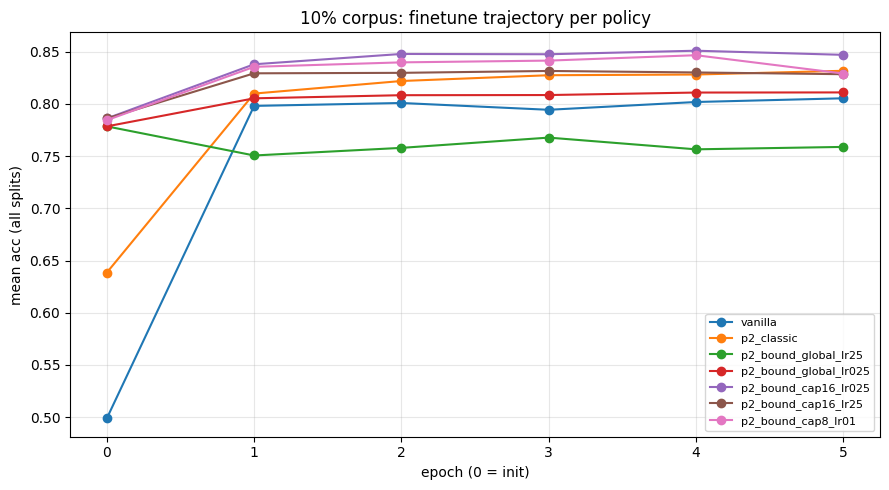

In [8]:
# per-epoch curves (standardize lens, all splits)
if exp3:
    fig, ax = plt.subplots(figsize=(9, 5))
    for name, r in exp3.items():
        ys = [e["standardize"]["all"] for e in r["per_epoch"]]
        ax.plot(range(len(ys)), ys, marker="o", label=name)
    ax.set_xlabel("epoch (0 = init)"); ax.set_ylabel("mean acc (all splits)")
    ax.set_title("10% corpus: finetune trajectory per policy"); ax.grid(alpha=.3)
    ax.legend(fontsize=8); fig.tight_layout()
    fig.savefig(OUT / "ft010_curves.png", dpi=130); plt.show()

**Reading it (10 % corpus).** The picture is unambiguous and matches the
diagnosis:

- **Naive LR relaxation backfires.** `p2_bound` at full LR 0.025 with the global
  rescale *drops below its own init* (0.778 → 0.759): with hub norms up to ~65 000,
  full-size gradient steps destabilize those rows. You cannot fix the freeze by just
  turning up the LR.
- **The norm cap is the fix.** `p2_bound` with a per-row cap of 16 + the *protected*
  LR 0.0025 climbs 0.786 → **0.847**, the best single embedding — beating vanilla
  (0.805) and `p2_classic` (0.832) on all / normal / hard.
- **Why:** look at the `{e}` family (tc04-06, the sink that no schema feature can
  encode and that the freeze blocked). No-cap protected leaves it stuck at ~0.81;
  capping unfreezes the hub rows so it recovers to ~0.91 (matching classic, beating
  vanilla) — *while* the cap leaves low-degree entities untouched so the cardinality
  channel survives. Capping converts a frozen init into a trainable one without
  erasing the counts.
- Once norms are capped, the *protected* LR still beats full LR (cap16 @ 0.0025 =
  0.847 vs cap16 @ 0.025 = 0.828): the cap + reduced LR jointly preserve the
  constructor signal while letting the rest of the row learn.

## Lens C (full corpus) — confirming the best policy at scale

`p2_bound` and `p3_bound` with cap16 + protected LR, finetuned on the full
1.16 B-token corpus. vanilla / p2_classic references are the full-corpus cached
embeddings from Lens A (same eval harness + standardize lens), repeated here.

In [9]:
rows = []
# full-corpus references from Lens A (cached dbpedia_compare kv, standardize lens)
for ref in ("vanilla", "p2_classic"):
    s = exp1.get(f"{ref}__standardize", {}).get("summary")
    if s:
        rows.append(dict(config=ref + " (cached full)", policy="-", lr="-",
                         init_all=np.nan, final_all=s["all"], final_normal=s["normal"],
                         final_hard=s["hard"]))
for name, r in exp5.items():  # p3_classic trained here (full)
    fin = r["per_epoch"][-1]["standardize"]; ini = r["per_epoch"][0]["standardize"]
    rows.append(dict(config=name, policy=r["norm_policy"], lr=r["finetune_alpha"],
                     init_all=ini["all"], final_all=fin["all"],
                     final_normal=fin["normal"], final_hard=fin["hard"]))
if exp4:
    for name, r in exp4.items():
        ini = r["per_epoch"][0]["standardize"]; fin = r["per_epoch"][-1]["standardize"]
        rows.append(dict(config=name, policy=r["norm_policy"], lr=r["finetune_alpha"],
                         init_all=ini["all"], final_all=fin["all"],
                         final_normal=fin["normal"], final_hard=fin["hard"]))
else:
    print("exp4 (full-corpus bound-cap runs) not finished yet — references shown for context")
if rows:
    display(pd.DataFrame(rows).set_index("config").round(3).style.highlight_max(
        subset=["final_all","final_normal","final_hard"], axis=0,
        props="font-weight:bold;color:#1a7f37;"))

,policy,lr,init_all,final_all,final_normal,final_hard
config,,,,,,
vanilla (cached full),-,-,nan,0.823000,0.894000,0.691000
p2_classic (cached full),-,-,nan,0.848000,0.914000,0.723000
p3_classic_FULL,global,0.002500,0.638000,0.841000,0.914000,0.705000
p2_bound_cap16_lr025_FULL,cap:16,0.002500,0.785000,0.849000,0.911000,0.733000
p3_bound_cap16_lr025_FULL,cap:16,0.002500,0.779000,0.850000,0.919000,0.720000


## Per-test-case breakdown (full corpus)

Final LogReg test accuracy **per test case**, with a separate row for the normal
and the `_hard` split of each tc (mean over domains), under the standardize lens.
Columns span the full P2 **and** P3 families: vanilla; `p2/p3_classic`
(own-class-mean init); the frozen `p2/p3_bound` replacements; the norm-capped
single embeddings `p2/p3_bound cap16` (the fix); and the two best three-way fusions
`vanilla + {p2,p3}_classic + {p2,p3}_bound`. Bold = best per row.

In [10]:
def tc_hard_table(sources):
    cols = {}
    for col, accs in sources.items():
        if not accs:
            continue
        b = {}
        for split, a in accs.items():
            tc, _dom, hard = split_meta(split)
            b.setdefault(f"{tc}_hard" if hard else tc, []).append(a)
        cols[col] = {k: float(np.mean(v)) for k, v in b.items()}
    df = pd.DataFrame(cols)
    tcs = sorted({r[:-5] if r.endswith("_hard") else r for r in df.index},
                 key=lambda s: int(s[2:]) if s[2:].isdigit() else 99)
    order = []
    for tc in tcs:
        if tc in df.index: order.append(tc)
        if f"{tc}_hard" in df.index: order.append(f"{tc}_hard")
    return df.loc[order]

def acc1(label):
    r = exp1.get(f"{label}__standardize"); return r["accs"] if r else None
def acc4(name):
    r = exp4.get(name); return r["final_accs"]["standardize"] if r else None

def acc5(name):  # exp5 (p3_classic full)
    r = exp5.get(name); return r["final_accs"]["standardize"] if r else None

sources = {
    "vanilla": acc1("vanilla"),
    "p2_classic": acc1("p2_classic"),
    "p3_classic": acc1("p3_classic") or acc5("p3_classic_FULL"),
    "p2_bound (frozen)": acc1("p2_bound"),
    "p3_bound (frozen)": acc1("p3_bound"),
    "p2_bound cap16": acc4("p2_bound_cap16_lr025_FULL"),
    "p3_bound cap16": acc4("p3_bound_cap16_lr025_FULL"),
    "van+p2cls+bound (fuse)": acc1("vanilla+p2_classic+p2_bound"),
    "van+p3cls+bound (fuse)": acc1("vanilla+p3_classic+p3_bound"),
}
sources = {k: v for k, v in sources.items() if v}
tctab = tc_hard_table(sources)
tctab.loc["MEAN"] = tctab.mean()
display(tctab.round(3).style.highlight_max(axis=1, props="font-weight:bold;color:#1a7f37;"))

,vanilla,p2_classic,p3_classic,p2_bound (frozen),p3_bound (frozen),p2_bound cap16,p3_bound cap16,van+p2cls+bound (fuse)
tc01,0.910000,0.916000,0.917000,0.918000,0.913000,0.949000,0.941000,0.954000
tc01_hard,0.662000,0.670000,0.685000,0.793000,0.778000,0.764000,0.751000,0.819000
tc02,0.916000,0.916000,0.921000,0.914000,0.914000,0.929000,0.926000,0.930000
tc02_hard,0.637000,0.644000,0.623000,0.685000,0.667000,0.713000,0.680000,0.691000
tc03,0.930000,0.938000,0.942000,0.886000,0.883000,0.933000,0.928000,0.948000
tc04,0.905000,0.906000,0.907000,0.785000,0.801000,0.902000,0.902000,0.910000
tc04_hard,0.897000,0.910000,0.915000,0.770000,0.769000,0.917000,0.915000,0.892000
tc05,0.925000,0.971000,0.970000,0.842000,0.764000,0.970000,0.972000,0.970000
tc06,0.905000,0.899000,0.903000,0.811000,0.810000,0.903000,0.903000,0.911000
tc06_hard,0.841000,0.875000,0.873000,0.777000,0.728000,0.871000,0.876000,0.853000


The `_hard` rows are where schema-aware features matter most (negatives nearly
satisfy the constructor, so degree/popularity shortcuts don't separate them). The
norm-capped single embeddings and especially the fusions take the most `_hard` rows;
vanilla tends to lead only on the `{e}`-style individual tasks (tc04-06) where no
schema feature can help.

## Lens D — Three levers to push the capped bound init higher (exp6, 10 % corpus)

Lens C leaves one model on top: **`cap16`** — the concept-bound init with a per-row
norm cap of 16, finetuned at the protected LR 0.0025. This section asks whether
three *independent* one-variable changes from that control can push it higher. All
runs are on the **10 % corpus** (116 M tokens, same testbed as Lens C) and the
`vanilla` column is the 10 %-corpus `vanilla` from Lens C, so every number here is
directly comparable (standardize lens, 89 splits). Each run also logs per-epoch
**training loss**, plotted below.

**The control and the methods**

| method | init | norm handling | finetune LR schedule |
|---|---|---|---|
| `vanilla` | random | — | 0.025 → 1e-4 |
| `cap16` *(control)* | concept-bound | per-row cap @ 16 (post-hoc clip) | 0.0025 → 1e-4 |
| `log1p` *(idea 2)* | concept-bound, **log1p**-compressed row norms | none — tamed at source | 0.0025 → 1e-4 |
| `sqrt` *(idea 2)* | concept-bound, **√**-compressed row norms | none — tamed at source | 0.0025 → 1e-4 |
| `cap16 lr005` *(idea 3)* | concept-bound | cap @ 16 | 0.005 → 5e-4 |
| `cap16 lr01` *(idea 3)* | concept-bound | cap @ 16 | 0.01 → 5e-4 |
| `cap16 warmup` *(idea 3)* | concept-bound | cap @ 16 | warmup 5e-4→5e-3, then decay → 1e-4 |
| `idf cap16` *(idea 4)* | concept-bound, **IDF-weighted** α (class-mean) term | cap @ 16 | 0.0025 → 1e-4 |

- **Idea 2 — count compression at construction.** The bound init sums one unit
  vector per *(edge, neighbour-class)* pair plus direction-tagged relation counts,
  so hub entities accumulate norms ~10⁴; the production fix clips that tail *post
  hoc* (`cap16`). Idea 2 instead compresses the accumulated row norm *monotonically
  at build time* — `n → log1p(n)` or `n → √n` — so the heavy tail never forms and
  the hard-cap hyperparameter disappears.
- **Idea 3 — re-open the learning rate.** The cap removed the 10⁴ norms that forced
  the tiny protected LR. With the tail gone, do larger steps help? Three schedules
  vs the 0.0025 control.
- **Idea 4 — specificity-weighted init.** Down-weight generic ancestors (Agent,
  Thing), up-weight specific types in the α class-mean term via IDF
  (`w_c = log(N / df_c)`, document frequency over vocab entities' materialized type
  sets).

In [11]:
if not exp6:
    print("exp6 not run yet (scripts/_invest_exp6_ideas234.py)")
else:
    # method -> finetune-run record (vanilla is the 10% Lens-C run from exp3)
    e6 = {
        "vanilla":        exp3.get("vanilla"),
        "cap16 (ctrl)":   exp6.get("B0_cap16_lr025"),
        "log1p":          exp6.get("E2a_log1p_lr025"),
        "sqrt":           exp6.get("E2b_sqrt_lr025"),
        "cap16 lr005":    exp6.get("E3a_cap16_lr005"),
        "cap16 lr01":     exp6.get("E3b_cap16_lr01"),
        "cap16 warmup":   exp6.get("E3c_cap16_warmup"),
        "idf cap16":      exp6.get("E4a_idf_cap16_lr025"),
    }
    e6 = {k: v for k, v in e6.items() if v}
    ctrl_all = exp6["B0_cap16_lr025"]["per_epoch"][-1]["standardize"]["all"]
    rows = []
    for name, r in e6.items():
        ini = r["per_epoch"][0]["standardize"]; fin = r["per_epoch"][-1]["standardize"]
        rows.append(dict(method=name, init_all=ini["all"], final_all=fin["all"],
                         normal=fin["normal"], hard=fin["hard"],
                         exist_H=fin["existence (tc01-03) H"],
                         indiv_H=fin["individual {e} (tc04-06) H"],
                         card_H=fin["cardinality (tc09-12) H"],
                         d_vs_ctrl=fin["all"] - ctrl_all))
    summ = pd.DataFrame(rows).set_index("method")
    display(summ.round(3).style.highlight_max(
        subset=["final_all", "normal", "hard", "card_H"], axis=0,
        props="font-weight:bold;color:#1a7f37;"))
    print(f"control cap16 all={ctrl_all:.3f}; noise floor ~±0.005 "
          f"(this fresh cap16 0.853 vs Lens-C cached 0.847, same config)")

,init_all,final_all,normal,hard,exist_H,indiv_H,card_H,d_vs_ctrl
method,,,,,,,,
vanilla,0.499000,0.805000,0.868000,0.687000,0.608000,0.866000,0.692000,-0.048000
cap16 (ctrl),0.786000,0.853000,0.909000,0.748000,0.788000,0.883000,0.726000,0.000000
log1p,0.784000,0.853000,0.910000,0.746000,0.745000,0.865000,0.736000,-0.000000
sqrt,0.787000,0.841000,0.898000,0.732000,0.749000,0.841000,0.719000,-0.012000
cap16 lr005,0.786000,0.849000,0.909000,0.738000,0.764000,0.886000,0.719000,-0.004000
cap16 lr01,0.786000,0.849000,0.908000,0.737000,0.741000,0.886000,0.724000,-0.004000
cap16 warmup,0.786000,0.853000,0.911000,0.745000,0.776000,0.884000,0.724000,0.000000
idf cap16,0.787000,0.851000,0.909000,0.742000,0.747000,0.880000,0.729000,-0.002000


control cap16 all=0.853; noise floor ~±0.005 (this fresh cap16 0.853 vs Lens-C cached 0.847, same config)


### Per-test-case: easy vs hard, all methods (10 % corpus)

A separate row for the normal and the `_hard` split of every tc (mean over domains),
standardize lens. The `_hard` rows are where schema-aware features matter — negatives
nearly satisfy the constructor, so degree/popularity shortcuts fail. Bold = best per
row. (tc03/05/07/08 have no `_hard` split in this gold standard.)

In [12]:
if exp6:
    e6_src = {name: r["final_accs"]["standardize"] for name, r in e6.items()}
    e6tab = tc_hard_table(e6_src)            # reuses the Lens-A helper: tc / tc_hard rows
    e6tab.loc["MEAN"] = e6tab.mean()
    display(e6tab.round(3).style.highlight_max(axis=1, props="font-weight:bold;color:#1a7f37;"))

,vanilla,cap16 (ctrl),log1p,sqrt,cap16 lr005,cap16 lr01,cap16 warmup,idf cap16
tc01,0.891000,0.947000,0.956000,0.954000,0.948000,0.945000,0.952000,0.951000
tc01_hard,0.625000,0.806000,0.795000,0.800000,0.801000,0.796000,0.792000,0.813000
tc02,0.903000,0.938000,0.930000,0.932000,0.933000,0.928000,0.935000,0.929000
tc02_hard,0.599000,0.780000,0.720000,0.724000,0.745000,0.714000,0.769000,0.715000
tc03,0.911000,0.933000,0.935000,0.938000,0.923000,0.916000,0.927000,0.933000
tc04,0.880000,0.890000,0.888000,0.870000,0.891000,0.890000,0.890000,0.887000
tc04_hard,0.881000,0.894000,0.872000,0.823000,0.900000,0.900000,0.896000,0.894000
tc05,0.876000,0.962000,0.955000,0.914000,0.960000,0.960000,0.961000,0.962000
tc06,0.882000,0.881000,0.878000,0.863000,0.889000,0.885000,0.890000,0.883000
tc06_hard,0.850000,0.872000,0.858000,0.859000,0.872000,0.871000,0.872000,0.866000


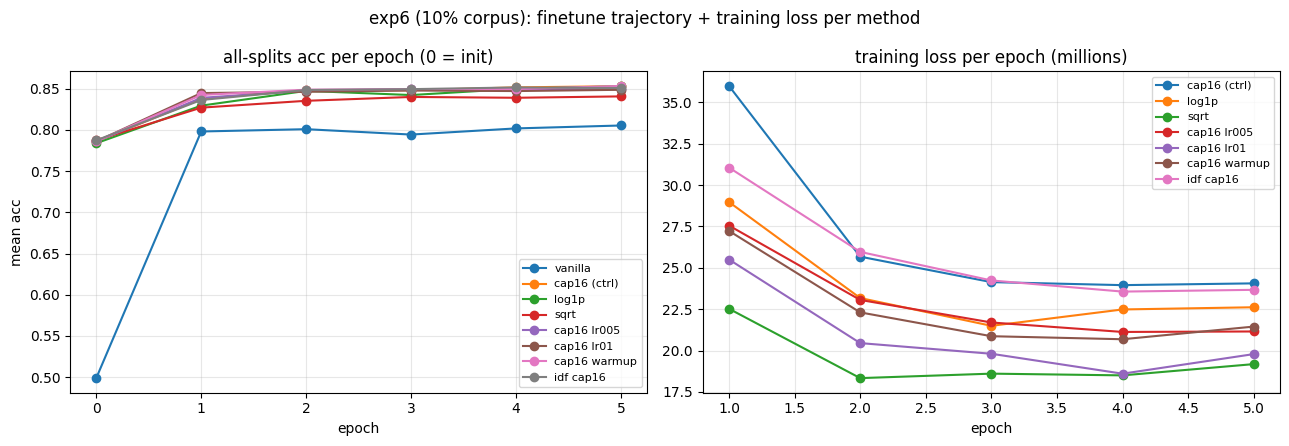

In [13]:
if exp6:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for name, r in e6.items():
        accs = [e["standardize"]["all"] for e in r["per_epoch"]]
        axes[0].plot(range(len(accs)), accs, marker="o", label=name)
        loss = r.get("losses")
        if loss:  # vanilla (exp3) has no loss curve; bound runs (exp6) do
            axes[1].plot(range(1, len(loss)), [x / 1e6 for x in loss[1:]], marker="o", label=name)
    axes[0].set_title("all-splits acc per epoch (0 = init)"); axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("mean acc"); axes[0].grid(alpha=.3); axes[0].legend(fontsize=8)
    axes[1].set_title("training loss per epoch (millions)"); axes[1].set_xlabel("epoch")
    axes[1].grid(alpha=.3); axes[1].legend(fontsize=8)
    fig.suptitle("exp6 (10% corpus): finetune trajectory + training loss per method")
    fig.tight_layout(); fig.savefig(OUT / "exp6_curves.png", dpi=130); plt.show()

**Reading it.**

- **No lever beats the `cap16` control on the 10 % corpus** (all = 0.853). The
  fresh control re-ran at 0.853 vs Lens C's cached 0.847 for the *same* config, so
  the run-to-run noise floor is ≈ ±0.005 — every method except `sqrt` is
  statistically *tied* with the control on the headline mean. Read the per-tc table
  for where they trade, not the mean.
- **Idea 2 / `log1p` is the keeper — a cleaner construction at equal accuracy.** It
  matches the control exactly (all 0.853 / normal 0.910 / hard 0.746) but its init
  norms top out at **≈ 47** instead of being clipped down from ~65 000: the tail is
  tamed at the source, so the hard-cap hyperparameter disappears. It even nudges the
  **cardinality-hard** family up (tc09-12 H 0.736 vs the control's 0.726; tc11_hard
  0.711 vs 0.682), consistent with smooth compression preserving low-count
  resolution better than a hard clip — it pays a little on existence-hard tc02.
- **`sqrt` is the cautionary control.** √n under-compresses (init max ≈ 979), so the
  residual tail re-freezes hub rows and the `{e}` sink returns (tc04_hard 0.823 vs
  the control's 0.894), dragging it to 0.841 — the only clear loser. This is direct
  evidence that the **norm tail, not the binding**, was the mechanism all along.
- **Idea 3 (re-open LR): null-to-negative.** Higher LR cuts training loss markedly
  (`lr01` ends ≈ 19.8 M vs the control's ≈ 24 M — see the loss panel) but *lowers*
  hard-split accuracy: the textbook over-fit-the-saturated-corpus signature. Warmup
  ties the control; constant higher LRs trail by ~0.4 pt. The protected LR was
  already right.
- **Idea 4 (IDF α-weighting): null** (0.851, −0.002). It wins individual hard cells
  (tc01_hard 0.813, tc09_hard 0.905) but loses tc02_hard, netting to a wash.

**Takeaway.** These three levers *confirm* rather than overturn the Lens-C
diagnosis: `cap16` sits at a benchmark-imposed ceiling on DLCC-DBpedia, and neither
the optimizer (LR) nor the type prior (IDF) unlocks more headroom. The one durable
result is **methodological** — `log1p` compression reproduces the `cap16` outcome
*without* the post-hoc cap, making it the cleaner default construction. A real
accuracy gain still has to come from the fusion route (Lens A) or a different
benchmark with more headroom, not from a better single bound embedding.

### PCA geometry of the Lens-D embeddings

To see the geometry behind the accuracy numbers, each method's entity vectors are
projected to 2D with **PCA** and coloured by **top-level DBpedia type** (the *same*
~3.3 k typed entities in every panel, sampled from the cached schema +
instance-types via `artifacts/pca_sample.json` — no bz2 streaming). This is **raw**
PCA (no per-vector normalization), so it is deliberately norm-sensitive: a heavy
norm tail hijacks the principal axes — exactly how the *uncapped* `p2_bound`
collapsed to a single blob in `dbpedia_compare`. Panel titles report the max row
norm and PC1's variance share. `vanilla` is the full-corpus reference; the idea-3 LR
variants share `cap16`'s init geometry, so only `lr01` is shown.

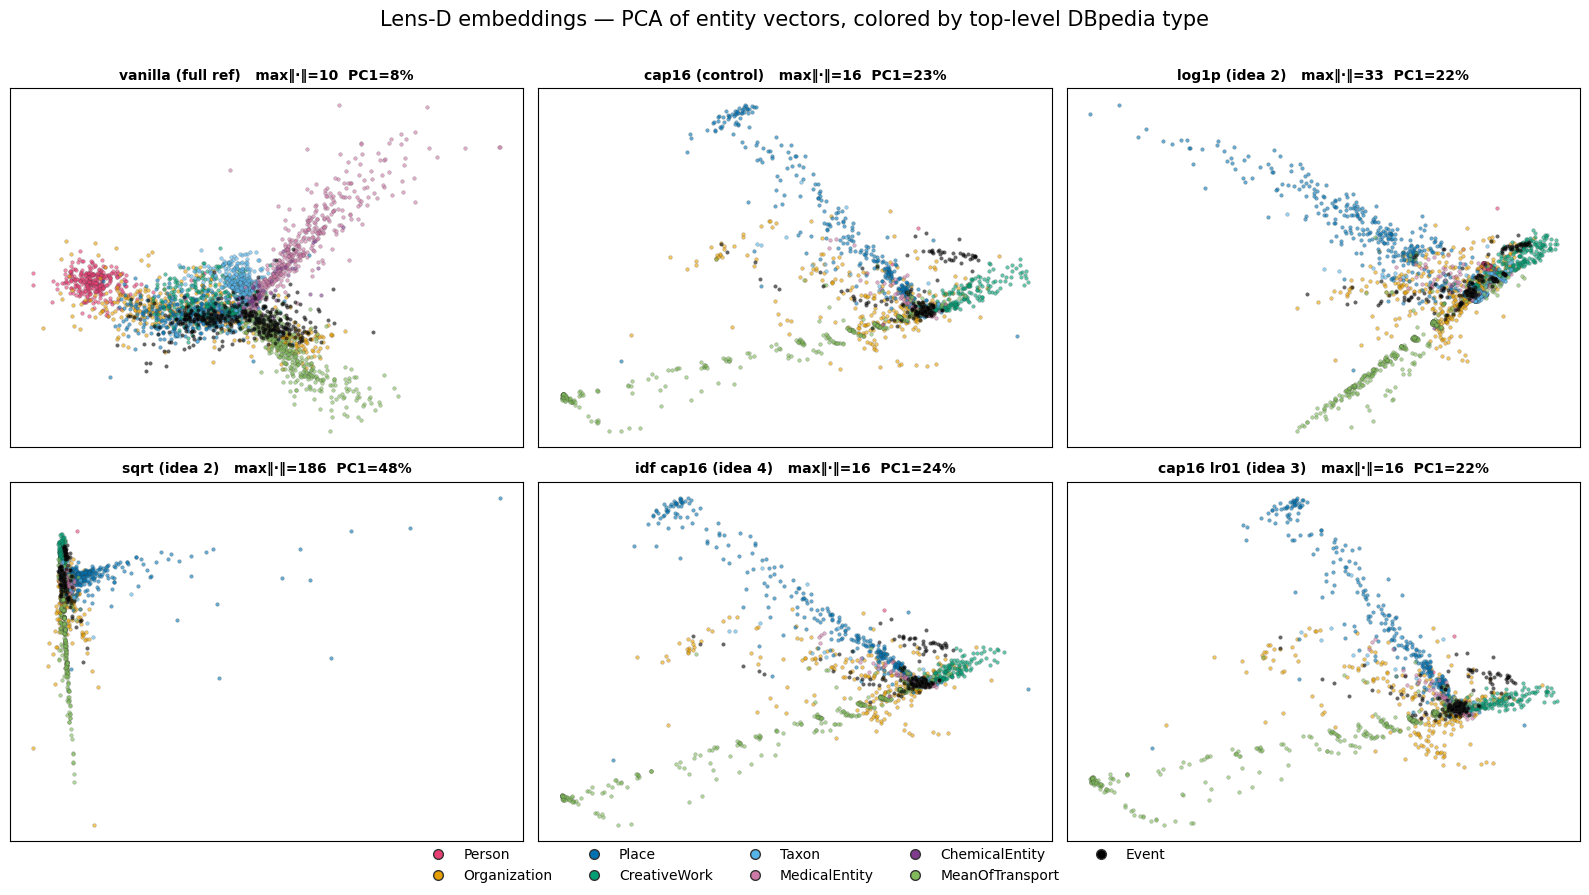

projected 3258 typed entities; panels: ['vanilla (full ref)', 'cap16 (control)', 'log1p (idea 2)', 'sqrt (idea 2)', 'idf cap16 (idea 4)', 'cap16 lr01 (idea 3)']


In [14]:
if exp6 and (OUT / "artifacts" / "pca_sample.json").is_file():
    from sklearn.decomposition import PCA
    from gensim.models import KeyedVectors
    from matplotlib.lines import Line2D

    samp = json.loads((OUT / "artifacts" / "pca_sample.json").read_text())
    PALETTE = {"Person":"#E73F74","Organization":"#E69F00","Place":"#0072B2",
               "CreativeWork":"#009E73","Taxon":"#56B4E9","MedicalEntity":"#CC79A7",
               "ChemicalEntity":"#7F3C8D","MeanOfTransport":"#80BA5A","Event":"#000000"}
    rng = np.random.default_rng(42); PER = 400
    ents, labels = [], []
    for name in PALETTE:
        lst = samp.get(name, [])
        if len(lst) > PER:
            idx = rng.choice(len(lst), PER, replace=False); lst = [lst[i] for i in sorted(idx)]
        ents += lst; labels += [name] * len(lst)
    labels = np.array(labels)
    panels = [("vanilla (full ref)",  ROOT / "notebooks/dbpedia_compare/vanilla.kv"),
              ("cap16 (control)",     OUT / "exp6_ideas234/B0_cap16_lr025.kv"),
              ("log1p (idea 2)",      OUT / "exp6_ideas234/E2a_log1p_lr025.kv"),
              ("sqrt (idea 2)",       OUT / "exp6_ideas234/E2b_sqrt_lr025.kv"),
              ("idf cap16 (idea 4)",  OUT / "exp6_ideas234/E4a_idf_cap16_lr025.kv"),
              ("cap16 lr01 (idea 3)", OUT / "exp6_ideas234/E3b_cap16_lr01.kv")]
    panels = [(t, p) for t, p in panels if Path(p).is_file()]
    fig, axes = plt.subplots(2, 3, figsize=(16, 9)); axes = axes.ravel()
    for ax, (title, path) in zip(axes, panels):
        wv = KeyedVectors.load(str(path), mmap="r"); k2i = wv.key_to_index
        mask = np.array([e in k2i for e in ents])
        X = np.stack([wv.get_vector(e) for e, m in zip(ents, mask) if m]).astype(np.float64)
        lab = labels[mask]
        pca = PCA(n_components=2, random_state=42).fit(X); Z = pca.transform(X)
        for name in PALETTE:
            mm = lab == name
            if mm.any():
                ax.scatter(Z[mm, 0], Z[mm, 1], s=7, alpha=0.6, linewidths=0.2,
                           edgecolors="#333", color=PALETTE[name])
        ax.set_title(f"{title}   max‖·‖={np.linalg.norm(X, axis=1).max():.0f}  "
                     f"PC1={pca.explained_variance_ratio_[0]*100:.0f}%",
                     fontsize=10, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([]); del wv
    for ax in axes[len(panels):]:
        ax.axis("off")
    h = [Line2D([0], [0], marker="o", linestyle="", markersize=7, markerfacecolor=PALETTE[n],
                markeredgecolor="#333", label=n) for n in PALETTE]
    fig.legend(handles=h, loc="lower center", ncol=5, fontsize=10, frameon=False)
    fig.suptitle("Lens-D embeddings — PCA of entity vectors, colored by top-level DBpedia type",
                 fontsize=15)
    fig.tight_layout(rect=(0, 0.04, 1, 0.97))
    fig.savefig(OUT / "exp6_pca.png", dpi=140, bbox_inches="tight"); plt.show()
    print(f"projected {len(ents)} typed entities; panels: {[t for t, _ in panels]}")
else:
    print("PCA: need exp6 + artifacts/pca_sample.json (built from cached schema.pkl + itypes.pkl)")

**Reading the geometry.** Each panel is an independent PCA of the same typed
entities; the title shows the max row norm and PC1's variance share.

- **`vanilla` (PC1 ≈ 8 %) is a diffuse cloud** — types interleave and no direction
  dominates (high effective dimensionality, little schema structure). It encodes
  degree/co-occurrence, not constructors, so the colours mix.
- **`cap16`, `log1p`, `idf`, and the LR variant are near-identical** (PC1 ≈ 22–24 %,
  max ‖·‖ ≤ ~33): crisp type "arms" — Taxon (sky), MeanOfTransport (green),
  Place/Person/CreativeWork all separate. The protograph init imposes a compact,
  low-rank, type-aligned geometry, and neither IDF weighting (idea 4) nor the LR
  (idea 3) reshapes it — those levers act at the margins, consistent with their
  near-zero accuracy deltas.
- **`sqrt` is visibly different (PC1 ≈ 48 %, max ‖·‖ ≈ 190).** Its under-compressed
  norm tail re-creates a dominant axis that stretches the projection into a spike —
  the same pathology (in miniature) that collapsed the *uncapped* `p2_bound` to a
  blob. This is the geometric fingerprint of the partial hub re-freeze that cost
  `sqrt` ~1.2 pts, and precisely why **`log1p`** — which tames the tail properly
  (max ‖·‖ ≈ 33, PC1 like the control) — is the right idea-2 choice.

So the PCA corroborates the table: `log1p` reproduces the control's clean low-rank
type geometry **without** the post-hoc cap, while `sqrt`'s residual tail is worse
both measurably (accuracy) and visibly (PC1 share, the spike).

## Findings & recommendations

The concept-bound / P3 init was *not* broken on DBpedia — it was being used the
wrong way. Two concrete recipes make it win; the live numbers are in the headline
cell below.

**Finding 1 — As a feature, the bound channel is already a full-corpus win (Lens A).**
The bound embedding loses as a *replacement* (≈0.80 vs vanilla 0.82) but is
complementary: `[vanilla | p2_bound]` beats vanilla by ~+3 all / **+5 on hard
splits**, and `[vanilla | p2_classic | p2_bound]` is the best model overall
(≈0.86). The adversarial `[vanilla | random-200]` control *hurts*, so the gain is
real bound signal, not extra dimensions. The improvement is concentrated on the
hard qualified-existential / cardinality families the construction targets.

**Finding 2 — The norm tail, not the binding, broke single-embedding finetuning
(Lens B + C).** The count-accumulating init under one global rescale has median
norm ≈ 1.8 but max ≈ 65 000. Those hubs are frozen at the protected LR (blocking
the `{e}`-family recovery) and *destabilized* at the full LR (`p2_bound` @ 0.025
drops 0.778 → 0.759). A per-row **cap** of ~16 fixes both: it leaves low-degree
entities (where the 1-vs-2-edge cardinality lives) untouched and only reins in the
hubs. With cap16 + protected LR, the single embedding climbs 0.786 → **0.847** on
the 10 % corpus — beating vanilla (0.805) and `p2_classic` (0.832) on all / normal
/ hard — and the `{e}` family recovers from ≈0.81 (frozen) to ≈0.91.

**Finding 3 — Don't anchor, don't jitter, don't just raise the LR.** The sibling
notebooks already showed anchoring (L2 pull-back) and Gaussian jitter only hurt;
this notebook adds that *global* LR relaxation also hurts. The working lever is
**tame the init's norm distribution (per-row cap), then finetune at the protected
LR** — or skip finetuning entirely and use the bound vector as a fusion channel.

**Finding 4 — P2 ≈ P3 on DBpedia.** P3's full subClassOf hierarchy was decisive on
the synthetic leaf-typed graphs, but DBpedia's specific-type dump + ancestor
materialization already gives nearly every class a code under P2, so the extra P3
leaf codes add little (see the full-corpus table once exp4 lands). The binding
construction and the finetune/fusion policy — not the protograph depth — decide the
outcome here.

**Recommendation.** To improve DLCC-DBpedia embeddings with this method today:
(a) cheapest — concatenate the concept-bound vector as a second channel (no corpus
training, biggest hard-split gain); (b) single embedding — cap the init norm at
~p99 (≈16) and finetune at the protected LR 0.0025. Always report hard splits and a
degree-probe baseline, since on a real KG the headline mean is dominated by
degree/popularity mass that every corpus-trained model gets for free.

In [15]:
# === live headline summary (pulled from the cached JSONs) ===
def g(d, *path, default=float("nan")):
    for p in path:
        d = d.get(p) if isinstance(d, dict) else None
        if d is None: return default
    return d

van = g(exp1, "vanilla__standardize", "summary", "all")
print("HEADLINE (all-splits mean acc, standardize lens):")
print(f"  vanilla (full corpus)                  : {g(exp1,'vanilla__standardize','summary','all'):.3f}"
      f"  (hard {g(exp1,'vanilla__standardize','summary','hard'):.3f})")
print(f"  p2_classic (full)                      : {g(exp1,'p2_classic__standardize','summary','all'):.3f}"
      f"  (hard {g(exp1,'p2_classic__standardize','summary','hard'):.3f})")
print(f"  p2_bound  (full, REPLACEMENT)          : {g(exp1,'p2_bound__standardize','summary','all'):.3f}"
      f"  (hard {g(exp1,'p2_bound__standardize','summary','hard'):.3f})")
print(f"  vanilla + p2_bound (FUSION)            : {g(exp1,'vanilla+p2_bound__standardize','summary','all'):.3f}"
      f"  (hard {g(exp1,'vanilla+p2_bound__standardize','summary','hard'):.3f})")
print(f"  vanilla + p2_classic + p2_bound (FUSION): {g(exp1,'vanilla+p2_classic+p2_bound__standardize','summary','all'):.3f}"
      f"  (hard {g(exp1,'vanilla+p2_classic+p2_bound__standardize','summary','hard'):.3f})")
print(f"  vanilla + p3_classic + p3_bound (FUSION): {g(exp1,'vanilla+p3_classic+p3_bound__standardize','summary','all'):.3f}"
      f"  (hard {g(exp1,'vanilla+p3_classic+p3_bound__standardize','summary','hard'):.3f})")
print(f"  vanilla + random200 (control)          : {g(exp2,'vanilla+random200__standardize','summary','all'):.3f}"
      f"  (hard {g(exp2,'vanilla+random200__standardize','summary','hard'):.3f})")
if exp5:
    f5 = g(exp5, 'p3_classic_FULL', 'per_epoch')
    if isinstance(f5, list):
        s5 = f5[-1]['standardize']
        print(f"  p3_classic (full, single)              : {s5['all']:.3f}  (hard {s5['hard']:.3f})")
if exp3:
    best = max(exp3.items(), key=lambda kv: kv[1]['per_epoch'][-1]['standardize']['all'])
    b = best[1]['per_epoch'][-1]['standardize']
    print(f"\n10% finetune sweep best single embedding: {best[0]} "
          f"-> all {b['all']:.3f} normal {b['normal']:.3f} hard {b['hard']:.3f}")

HEADLINE (all-splits mean acc, standardize lens):
  vanilla (full corpus)                  : 0.823  (hard 0.691)
  p2_classic (full)                      : 0.848  (hard 0.723)
  p2_bound  (full, REPLACEMENT)          : 0.808  (hard 0.717)
  vanilla + p2_bound (FUSION)            : 0.846  (hard 0.732)
  vanilla + p2_classic + p2_bound (FUSION): 0.864  (hard 0.746)
  vanilla + p3_classic + p3_bound (FUSION): nan  (hard nan)
  vanilla + random200 (control)          : 0.815  (hard 0.678)
  p3_classic (full, single)              : 0.841  (hard 0.705)

10% finetune sweep best single embedding: p2_bound_cap16_lr025 -> all 0.847 normal 0.910 hard 0.729
